# Intro To LangChain

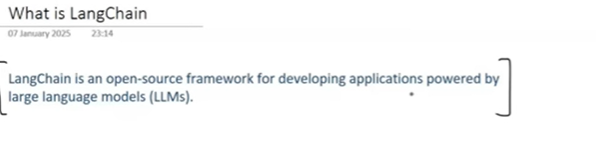

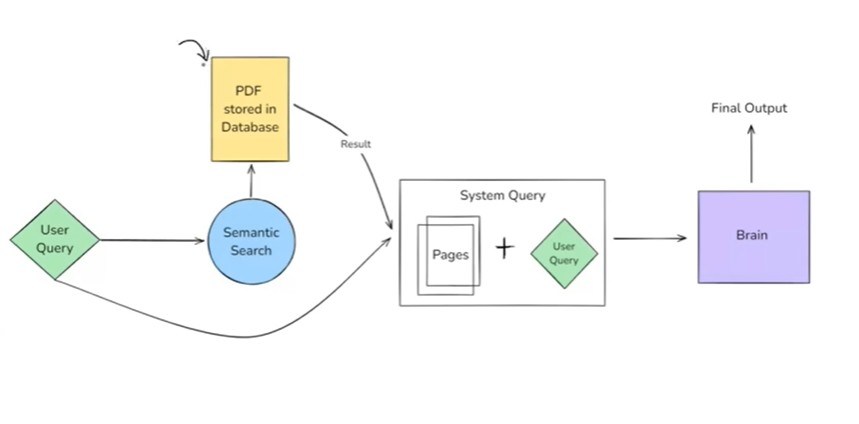

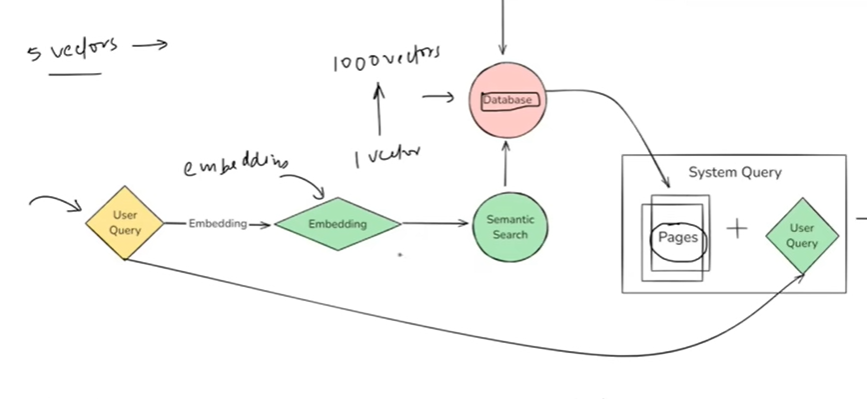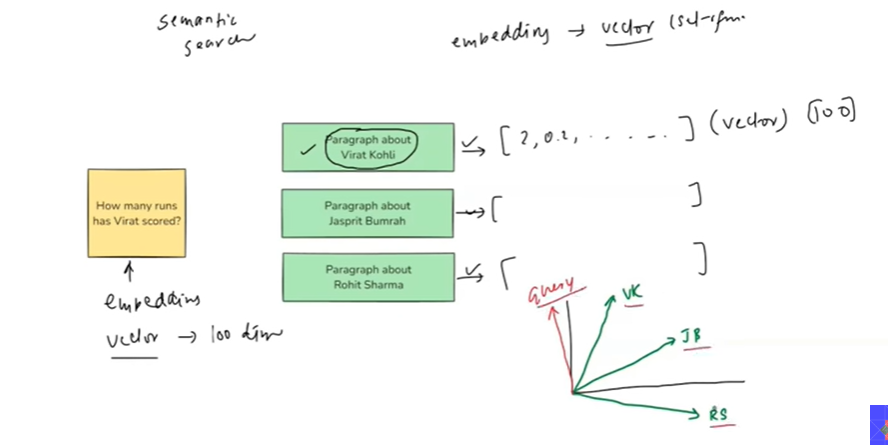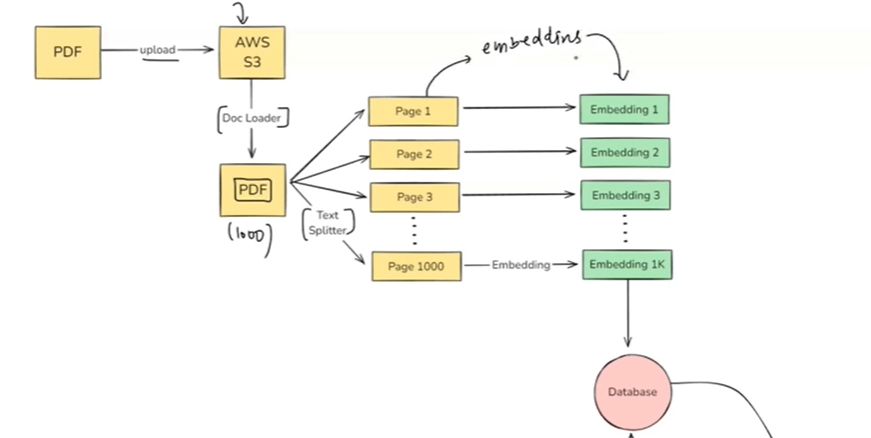

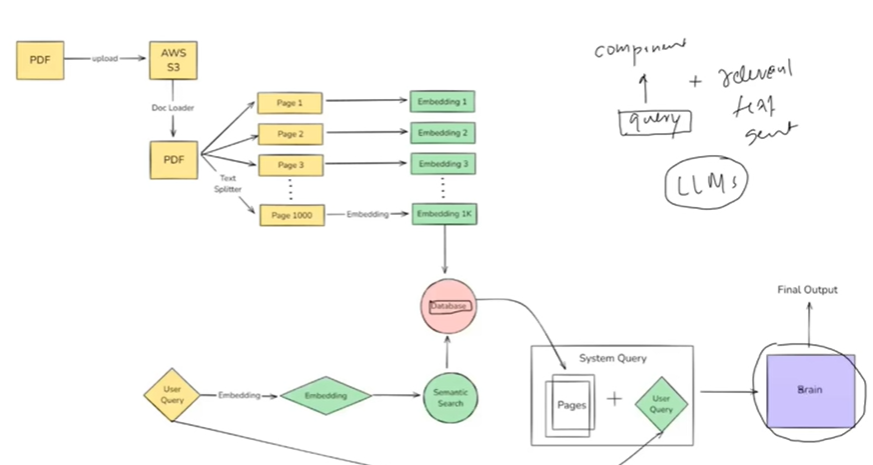

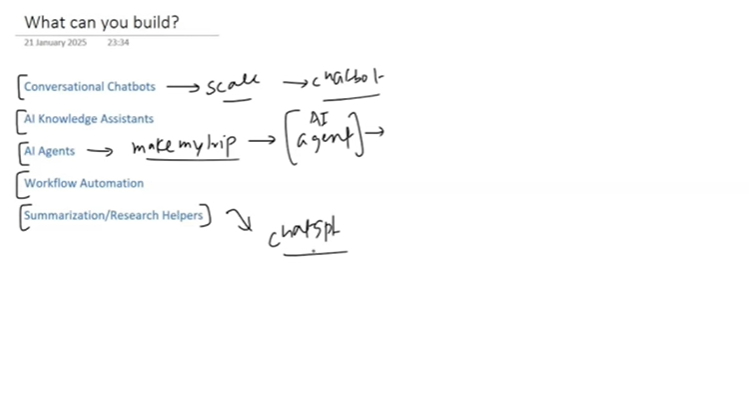

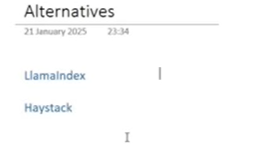

link - https://www.llamaindex.ai/

Haystack -https://haystack.deepset.ai/

To use the Gemini API, you'll need an API key. If you don't already have one, create a key in Google AI Studio.
In Colab, add the key to the secrets manager under the "🔑" in the left panel. Give it the name `GOOGLE_API_KEY`. Then pass the key to the SDK:

In [ ]:
# Import the Python SDK
import google.generativeai as genai
# Used to securely store your API key
from google.colab import userdata

GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

Before you can make any API calls, you need to initialize the Generative Model.

In [ ]:
# Initialize the Gemini API
gemini_model = genai.GenerativeModel('gemini-2.5-flash-preview-04-17')

Now you can make API calls. For example, to generate a poem:

In [ ]:
response = gemini_model.generate_content('Write a poem about the moon.')
print(response.text)

## Types of Generative AI Models

Generative AI encompasses a variety of models, each specializing in creating different types of content:

*   **Large Language Models (LLMs):** These models, like Gemini, are trained on vast amounts of text data to understand and generate human-like text. They can perform tasks such as writing, summarization, translation, and question-answering.
*   **Image Generation Models:** Models like Midjourney, DALL-E, or Stable Diffusion can create images from text descriptions (prompts).
*   **Code Generation Models:** These models can generate code snippets, complete functions, or even entire programs based on natural language descriptions.
*   **Audio and Video Generation Models:** Emerging models can generate synthetic speech, music, or even video content.
*   **Multimodal Models:** Advanced models, such as some versions of Gemini, can understand and generate content across multiple modalities, combining text, images, and potentially other forms of data.

Now, let's explore a more interactive way to use a large language model: a chat-based interaction.

## Conversational AI with Gemini (Chat Models)

Instead of single prompt-response interactions, you can engage in multi-turn conversations with a generative model. This allows the model to maintain context and build upon previous exchanges. The Gemini API supports this through its chat functionality.

You can continue the conversation by sending another message. The `chat` object will maintain the history of the conversation.

## All About LangChain

LangChain is a framework designed to simplify the creation of applications powered by large language models (LLMs). It provides a structured way to combine various components, making it easier to build complex LLM-based applications such as chatbots, question-answering systems, and agents that can interact with their environment.

### Why LangChain?

LLMs are incredibly powerful, but directly interacting with them can be limiting. LangChain addresses this by:

*   **Providing modular components:** It offers a suite of interchangeable modules (like LLMs, prompt templates, chains, and agents) that can be easily combined.
*   **Facilitating context management:** It helps manage conversation history and external data, crucial for more intelligent and continuous interactions.
*   **Enabling complex workflows:** It allows you to create intricate sequences of calls to LLMs and other tools, turning simple LLM calls into sophisticated applications.
*   **Offering integrations:** It seamlessly integrates with various LLMs, data sources, and tools (e.g., search engines, databases).

### Core Components of LangChain

LangChain is built around several core abstractions:

1.  **Models:** These are the language models themselves, like the Gemini model we're using. LangChain provides wrappers to interact with different types of models (LLMs for text generation, ChatModels for conversational interfaces, and Embeddings for text embeddings).

2.  **Prompts:** These are the inputs to the language models. LangChain offers `PromptTemplates` to easily construct and manage dynamic prompts, including few-shot examples and input variables.

3.  **Chains:** Chains are sequences of components that execute in a specific order. They allow you to combine LLMs with other tools (e.g., `LLMChain` for a simple LLM call, `SequentialChain` for multiple steps, `RetrievalQAChain` for Q&A over documents).

4.  **Retrievers:** Retrievers fetch documents or data from external sources to augment the LLM's knowledge. This is crucial for applications like Retrieval-Augmented Generation (RAG) where the LLM needs access to up-to-date or private information.

5.  **Agents:** Agents are more dynamic. They use an LLM as a reasoning engine to decide which actions to take and in what order. They can utilize various `Tools` (e.g., search, calculator) to achieve a goal, iterating until the task is complete.

Let's start by installing the necessary LangChain integration for Gemini and then creating a simple chain.

In [ ]:
# Install the LangChain integration for Google Generative AI
!pip install -q -U langchain-google-generativeai

In [ ]:
# Import necessary classes from LangChain
from langchain_google_generativeai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate

# Initialize the LangChain chat model with the Gemini model
# We're using the same 'gemini-2.5-flash-preview-04-17' model
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-preview-04-17", temperature=0.7)


Now, let's create a simple chain. We'll define a `ChatPromptTemplate` and then combine it with our `llm` model to form a chain.

In [ ]:
# Define a prompt template
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful AI assistant that answers questions in a concise manner."),
    ("user", "{question}")
])

# Create a simple chain by combining the prompt and the LLM
chain = prompt | llm

# Invoke the chain with a question
response = chain.invoke({"question": "What is the capital of France?"})
print(response.content)


In [ ]:
# Let's try another question
response = chain.invoke({"question": "What is the largest ocean on Earth?"})
print(response.content)
